# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Decision Tree | Random Forest 

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, and feature engineered.
Feature scaling is applied after splitting the data to prevent leakage, while class imbalance handling (SMOTE) is integrated within model training pipelines.

In [2]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus,LogCustomerValue
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.00,0,0,0,0,0,1,0,0,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,1,83807.86,0,0,1,0,0,1,0,0,11.336294
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.00,1,0,0,0,0,1,0,0,13.079421
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.00,0,0,0,0,1,0,0,0,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,1,125510.82,0,0,1,0,0,1,0,0,11.740155


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [4]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Feature Scaling

We apply StandardScaler after splitting to prevent data leakage.
The scaler is fitted only on training data then applied to test data.

In [5]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — only continuous numerical features
feature_scale_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue'
]

# Keep only columns that exist in our dataset
feature_scale_cols = [col for col in feature_scale_cols if col in X_train.columns]

scaler = StandardScaler()

# Fit on training data ONLY — prevents data leakage
X_train[feature_scale_cols] = scaler.fit_transform(X_train[feature_scale_cols])

# Apply same transformation to test data
X_test[feature_scale_cols] = scaler.transform(X_test[feature_scale_cols])

print("Scaling applied successfully!")
print("Scaled columns:", feature_scale_cols)

Scaling applied successfully!
Scaled columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue']


## 6. Handle Class Imbalance (SMOTE)

SMOTE is used to address class imbalance by generating synthetic samples for the minority class (churned customers).

To prevent data leakage and ensure proper evaluation, SMOTE is **not applied directly to the full training dataset here**. Instead, it is integrated within each model’s training pipeline, where it is applied only on the training folds during cross-validation.

This ensures that the model learns from balanced data while being evaluated on the original, imbalanced distribution.

In [6]:
from imblearn.over_sampling import SMOTE

# Show class distribution BEFORE applying SMOTE (for reference only)
before_dist = pd.Series(y_train).value_counts()

print("Before SMOTE - Class distribution:")
print(before_dist)

Before SMOTE - Class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64


## 7. Evaluation Metrics

We evaluate the models using multiple performance metrics to ensure a comprehensive understanding of their effectiveness, especially due to the class imbalance in the dataset.

Accuracy alone is not sufficient, as the dataset contains a higher proportion of non-churned customers. Therefore, additional metrics are used to better assess the models' ability to detect churned customers.

- **Accuracy:** Measures the overall percentage of correctly classified customers.
- **Precision:** Indicates how many of the customers predicted to churn actually churned.
- **Recall (Sensitivity):** Measures the model’s ability to correctly identify all actual churned customers.
- **F1-Score:** Provides a balance between precision and recall.
- **ROC-AUC Score:** Evaluates the model’s ability to distinguish between classes.

## 8. Model 1: Logistic Regression

### Overview
In this section we train a Logistic Regression model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation
### 8.1 Model Selection Rationale
Logistic Regression is selected based on the following dataset-specific reasons:
- **Binary target**: The dataset has a binary outcome (Exited = 0 or 1) which 
  Logistic Regression is specifically designed for
- **Pre-scaled features**:numerical features were standardized after train-test split to support model convergence.
- **Large sample size**: With 10,000 records and 19 features, Logistic Regression 
  trains efficiently without overfitting
- **Interpretability**: Coefficients directly show which features (e.g. Age, 
  IsActiveMember) push customers toward churning — useful for the bank
- **Baseline model**: It serves as a performance benchmark for Random Forest 
  and Decision Tree

### Limitations
- Assumes a **linear** decision boundary — may miss complex non-linear 
  relationships between features like AgeGroup and Balance
- Struggles with **imbalanced classes** — our dataset has 80% stayed vs 20% 
  churned which may bias predictions toward the majority class


### 8.2 Implementation & Training Code

The model is implemented using scikit-learn's LogisticRegression class.
An initial baseline model is trained below, followed by hyperparameter 
tuning in Section 8.3 to optimize performance.

In [7]:
# Initialize Logistic Regression with default parameters
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Logistic Regression trained successfully!
Initial Accuracy: 0.827


The high baseline accuracy is influenced by class imbalance, as predicting the majority class (non-churners) yields high accuracy but does not effectively identify churned customers.

### 8.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Logistic Regression.
We tune C (regularization strength), penalty, and solver to improve performance.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline: SMOTE + Logistic Regression
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

# Improved hyperparameter grid
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],  # lbfgs supports only l2
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

# Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 3))

# Best model
lr_model = grid_search.best_estimator_

# Predictions
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.504
Accuracy with best params: 0.729


### Hyperparameter Tuning Results

GridSearchCV evaluated multiple parameter combinations using 5-fold cross-validation, optimizing for **F1-score** to better handle class imbalance.

**Best Configuration:** `C=0.001`, `penalty=l2`, `solver=liblinear`

| Parameter | Value | Justification |
|----------|------:|---------------|
| C | 0.001 | Strong regularization — helps prevent overfitting and improves generalization |
| penalty | l2 | Ridge regularization — stabilizes coefficients without removing features |
| solver | liblinear | Suitable for smaller datasets and supports L2 regularization |

Although this configuration results in lower overall accuracy compared to the baseline model, it improves the model’s ability to detect churned customers by optimizing F1-score, which better reflects performance on the minority class.

### 8.4 Evaluation Metrics & Visualizations
We evaluate the Logistic Regression model using the previously defined metrics to assess its classification performance.

In [9]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.74      0.81      1593
 Churned (1)       0.40      0.69      0.51       407

    accuracy                           0.73      2000
   macro avg       0.65      0.72      0.66      2000
weighted avg       0.80      0.73      0.75      2000

ROC-AUC Score: 0.7754996907539279


### Evaluation Results

The model achieved an overall accuracy of **73%**. While this indicates reasonable overall performance, accuracy alone is not sufficient due to class imbalance in the dataset.

**Performance on Stayed class (0):**
- Precision: 0.90 — 90% of customers predicted to stay actually stayed
- Recall: 0.74 — 74% of actual non-churners were correctly identified
- F1-Score: 0.81 — strong performance on the majority class

**Performance on Churned class (1):**
- Precision: 0.40 — when churn is predicted, it is correct 40% of the time
- Recall: 0.69 — 69% of actual churners were detected
- F1-Score: 0.51 — moderate performance on the minority class

**ROC-AUC: 0.775**

**Key Finding:**  
The model demonstrates a clear performance gap between classes. While it performs well on the majority class (non-churners), its ability to accurately predict churners is more limited. This is partly due to the linear decision boundary of Logistic Regression, which may not fully capture complex, non-linear relationships in customer behavior.

### Metrics Interpretation

- **Stayed class:** A precision of 0.90 indicates the model rarely misclassifies churners as staying. The recall of 0.74 shows that most non-churning customers are correctly identified, contributing to high overall accuracy.

- **Churned class:** A precision of 0.40 indicates a high false positive rate — many customers predicted as churners are actually loyal. However, the recall of 0.69 is relatively strong, meaning the model successfully identifies most at-risk customers.

- **ROC-AUC (0.775):** The model has moderate ability to distinguish between churned and non-churned customers, performing significantly better than random guessing.

- **Business Perspective:** Recall is prioritized over precision in a bank retention system — missing a churner (false negative) is more costly than incorrectly flagging a loyal customer (false positive). Therefore, the model’s higher recall for churners is valuable despite lower precision.

### Logistic Regression - Confusion Matrix 

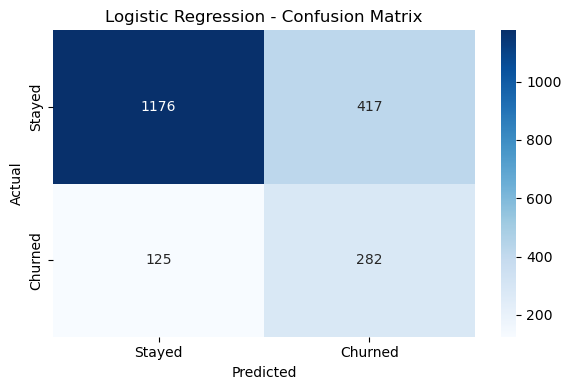

In [10]:
# Confusion Matrix heatmap - Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance:

- **True Negatives (1176):** The model correctly identified a large number of non-churning customers  
- **False Positives (417):** A significant number of non-churners were incorrectly predicted as churners, leading to unnecessary retention efforts  
- **False Negatives (125):** Some churners were missed by the model — predicted to stay but actually left, representing lost revenue opportunities  
- **True Positives (282):** The model successfully identified a majority of churned customers, enabling proactive retention actions  

### What this graph represents:

The confusion matrix compares actual vs predicted classifications, allowing us to evaluate how well the model performs for each class and identify where errors occur.

### Insight:

The model performs well in identifying customers who will stay, as shown by the high number of true negatives. It also captures a good portion of churners, but still misses some, as indicated by the false negatives.

Additionally, the relatively high number of false positives suggests that the model tends to over-predict churn, flagging some loyal customers as at risk.

### What we learned:

The model achieves a strong balance between detecting churners and maintaining overall performance.  

However, there is a trade-off:
- It prioritizes **recall (detecting churners)**  
- At the cost of **precision (more false alarms)**  

This behavior is acceptable in a business context, where missing a churner is more costly than incorrectly targeting a loyal customer.

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

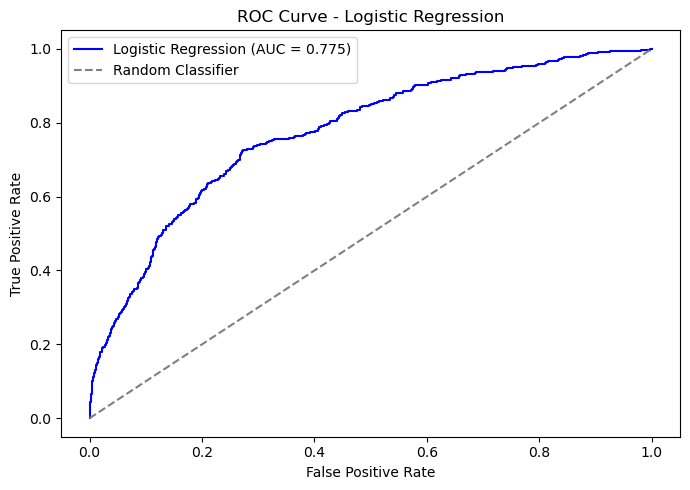

ROC-AUC Score: 0.7754996907539279


In [11]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", auc_score)

### ROC Curve Interpretation

**ROC-AUC Score: 0.775**

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

**Interpretation:**  
For a randomly selected pair of a churned and non-churned customer, the model assigns a higher churn probability to the actual churner approximately **77.5% of the time**. This falls within the "Fair to Good" range (0.7 – 0.8), indicating moderate discriminative ability.

### What this graph represents:

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds. It provides a threshold-independent measure of how well the model distinguishes between churned and non-churned customers.

### What we learned:

The moderate ROC-AUC reflects the limitations of Logistic Regression as a linear model. It cannot fully capture complex, non-linear relationships between features such as Age, Balance, and IsActiveMember, which are important in predicting customer churn.

Despite this, the model is reasonably effective at ranking customers by their likelihood of churn, even if it does not perfectly classify all cases.

### Logistic Regression - K-Fold Cross Validation


In [12]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline


lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42, 
                                  C=0.001, penalty='l2', solver='liblinear'))
])

cv_results = cross_validate(lr_pipeline, X_train, y_train, cv=5, 
                             scoring=['f1', 'roc_auc', 'accuracy'])

print("Logistic Regression - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", cv_results['test_f1'])
print("Mean F1:", cv_results['test_f1'].mean().round(3))
print("Std F1:", cv_results['test_f1'].std().round(3))
print("\nROC-AUC Scores:", cv_results['test_roc_auc'])
print("Mean ROC-AUC:", cv_results['test_roc_auc'].mean().round(3))
print("Std ROC-AUC:", cv_results['test_roc_auc'].std().round(3))
print("\nAccuracy Scores:", cv_results['test_accuracy'])
print("Mean Accuracy:", cv_results['test_accuracy'].mean().round(3))
print("Std Accuracy:", cv_results['test_accuracy'].std().round(3))

Logistic Regression - 5-Fold Cross Validation Results:
F1 Scores: [0.496614   0.51843318 0.50406504 0.51162791 0.48747153]
Mean F1: 0.504
Std F1: 0.011

ROC-AUC Scores: [0.76611994 0.77528147 0.769799   0.77496364 0.75580029]
Mean ROC-AUC: 0.768
Std ROC-AUC: 0.007

Accuracy Scores: [0.72125  0.73875  0.733125 0.7375   0.71875 ]
Mean Accuracy: 0.73
Std Accuracy: 0.008


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------:|------:|
| F1 Score | 0.504 | 0.011 |
| ROC-AUC  | 0.768 | 0.007 |
| Accuracy | 0.730 | 0.008 |

**Interpretation:**
- **F1 (0.504):** Moderate churn detection — consistent across all 5 folds with low variance
- **ROC-AUC (0.768):** Moderate discriminative ability — stable across different data splits
- **Accuracy (0.730):** Consistent across folds confirming model stability
- **Low standard deviation** across all metrics confirms the model generalizes well and results are not dependent on a specific data split

### 8.5 Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 73% |
| F1 - Stayed | 0.81 |
| F1 - Churned | 0.51 |
| ROC-AUC | 0.775 |


**What these metrics mean for our dataset:**
- **Accuracy (73%):** Overall correct classification rate across both classes, but may be misleading due to class imbalance
- **Precision (Churned = 0.40):** When churn is predicted, it is correct 40% of the time (indicates false alarms)
- **Recall (Churned = 0.69):** The model detects 69% of actual churners (important for retention)
- **F1-Score (Churned = 0.51):** Balanced measure between precision and recall for the minority class
- **ROC-AUC (0.775):** Moderate ability to distinguish between churned and non-churned customers


**Misclassification Analysis:**

| | Predicted Stayed | Predicted Churned |
|---|---|---|
| **Actually Stayed** | 1176 | 417 |
| **Actually Churned** | 125 | 282 |

- **125 False Negatives (missed churners):** Most costly — customers leave without retention intervention  
- **417 False Positives (false alarms):** Leads to unnecessary retention efforts toward loyal customers  


**Business Impact:**
The model detects **282 out of 407 churners (69% recall)**, allowing the bank to proactively target the majority of at-risk customers. However, the relatively high number of false positives (417) means retention resources may be spent on customers who were not planning to leave.


**Conclusion:**  
Logistic Regression provides a solid baseline for binary churn classification. While it performs well on the majority class, its linear decision boundary limits its ability to capture complex non-linear relationships in customer behavior. Future models such as Decision Trees and Random Forests are expected to improve precision while maintaining or enhancing recall.

### Save Evaluation Result

In [13]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned'])
with open('Supervised_Learning/evaluation_results/lr_classification_report.txt', 'w') as f:
    f.write(report)

print("Saved!")

Saved!


### Save Visualization

In [14]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_confusion_matrix.png')
plt.close()

# Save ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='blue', label=f'LR (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.close()

print("Plots saved successfully!")

Plots saved successfully!


## 9. Model 2: Decision Tree

### Overview
In this section we train a Decision Tree model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation

### 9.1 Model Selection Rationale
Decision Tree is selected based on the following dataset-specific reasons:
- **Non-linear relationships**: Customer churn is influenced by complex interactions between features such as Age, Balance, NumOfProducts, and IsActiveMember. Decision Trees can effectively capture these patterns.
- **Interpretability**: The model provides clear decision rules, making it easier to understand how features influence churn predictions.

### Limitations
- Can easily **overfit** the training data if not properly tuned
- Sensitive to small changes in the dataset, which may lead to different tree structures

### 9.2 Implementation & Training Code

The model is implemented using scikit-learn's DecisionTreeClassifier.
An initial model is trained below, followed by hyperparameter tuning in Section 9.3 to improve performance.

In [15]:
# Initialize Decision Tree with default parameters
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, dt_pred), 3))

Decision Tree trained successfully!
Initial Accuracy: 0.79


### 9.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [16]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

# Grid search with 5-fold cross validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best ROC-AUC Score:", dt_grid.best_score_.round(3))

# Retrain with best parameters
dt_model = dt_grid.best_estimator_
dt_pred = dt_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, dt_pred), 3))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}
Best ROC-AUC Score: 0.844
Accuracy with best params: 0.86


### Hyperparameter Tuning Results

GridSearchCV evaluated multiple parameter combinations using 5-fold cross-validation, optimizing for **ROC-AUC score** to better handle class imbalance.

**Best Configuration:** `max_depth=7`, `min_samples_split=100`, `min_samples_leaf=10`, `class_weight=None`

| Parameter | Value | Justification |
|----------|------:|---------------|
| max_depth | 7 | Controls tree depth to prevent overfitting while still capturing important patterns in customer behavior |
| min_samples_split | 100 | Prevents splits on small sample sizes, improving model generalization |
| min_samples_leaf | 10 | Ensures each leaf has enough samples, improving stability and reducing variance |
| class_weight | None | Re-weighting did not improve performance, indicating the model handles class distribution adequately |

### Observation

- The tuned model achieved an **accuracy of 0.86**, improving from the initial accuracy of **0.789**
- The ROC-AUC score reached **0.844**, indicating good ability to distinguish between churned and non-churned customers
- Overall, hyperparameter tuning successfully improved model performance

### 9.4 Evaluation Metrics & Visualizations

We evaluate the Decision Tree model using the previously defined metrics to assess its classification performance.

In [17]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, dt_proba))



Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.95      0.92      1593
 Churned (1)       0.72      0.51      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.8452466333822266


### Evaluation Results

The model achieved an overall accuracy of **86%**.

Performance on Stayed class (0):

- **Precision: 0.88** — 88% of customers predicted to stay actually stayed  
- **Recall: 0.95** — 95% of actual non-churners were correctly identified  
- **F1-Score: 0.92** — strong performance on the majority class  

Performance on Churned class (1):

- **Precision: 0.72** — when churn is predicted, it is correct 72% of the time  
- **Recall: 0.51** — only 51% of actual churners were detected  
- **F1-Score: 0.59** — moderate performance on the minority class  

**ROC-AUC: 0.845**

**Key Finding:** The model shows strong performance in identifying non-churning customers, but struggles to detect churned customers due to class imbalance. This indicates that further improvement is needed, particularly in increasing recall for the churned class.

### Metrics Interpretation

- **Stayed class (0):** High precision (0.88) and very high recall (0.95) — the model correctly identifies most non-churning customers with strong reliability  

- **Churned class (1):** Moderate precision (0.72) but low recall (0.51) — the model detects only about half of actual churners, meaning many churn cases are still missed  

- **ROC-AUC (0.845):** Indicates good overall ability to distinguish between churned and non-churned customers  

- **Class imbalance effect:** Performance is noticeably better for the majority class (stayed) compared to the minority class (churned), which is expected in imbalanced datasets  

- **Recall remains critical:** Missing churners is costly from a business perspective — improving recall for the churned class should be a priority in future improvements  

### Decision Tree - Confusion Matrix

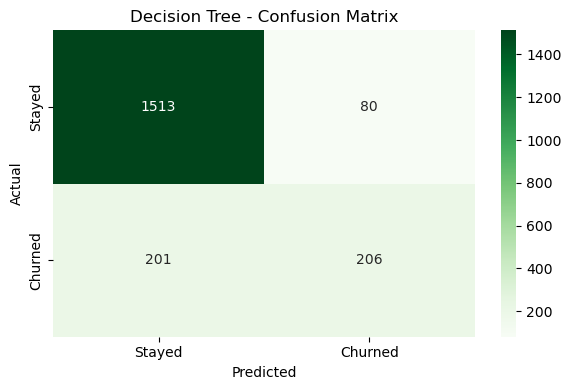

In [18]:
# Confusion Matrix heatmap - Decision Tree
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance:

- **True Negatives (1513)**: The model correctly identified a large number of non-churning customers  
- **False Positives (80)**: A small number of non-churners were incorrectly predicted as churners  
- **False Negatives (201)**: A significant number of churners were missed by the model  
- **True Positives (206)**: The model successfully identified some churned customers  

### What this graph represents:

The confusion matrix shows the comparison between actual and predicted classifications, allowing us to evaluate how well the model performs in identifying each class and where errors occur.

### Insight:

The model performs very well in identifying customers who will stay, as shown by the high number of true negatives. However, it struggles to detect all churners, as indicated by the relatively high number of false negatives.

This suggests that while the model is reliable for predicting non-churn, it still needs improvement in detecting at-risk customers.

### What we learned:

The model is highly effective at identifying non-churning customers but less effective at detecting churners.  

This highlights the impact of class imbalance and indicates that further improvements are needed to increase recall for the churned class, especially for business-critical decision making.

### Decision Tree - ROC Curve

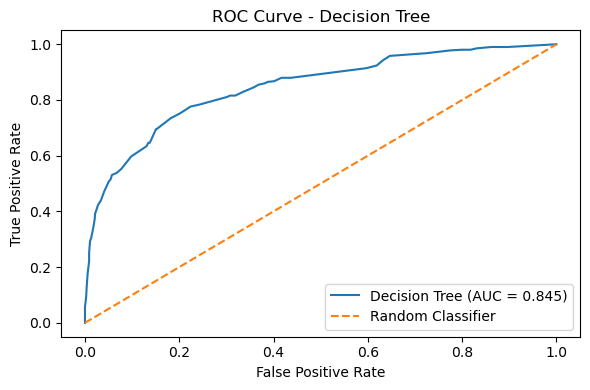

ROC-AUC Score: 0.8452466333822266


In [19]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

### ROC Curve Interpretation

ROC-AUC Score: 0.845

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

Interpretation: For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately 84.5% of the time. This falls within the "Good" range (0.8 – 0.9), indicating solid discriminative ability.

### What this graph represents:

The ROC curve shows the trade-off between the True Positive Rate (Recall) and False Positive Rate across different classification thresholds. It helps evaluate how well the model can distinguish between churned and non-churned customers regardless of a specific threshold.

### What we learned:

The improved ROC-AUC compared to Logistic Regression reflects the Decision Tree’s ability to capture non-linear relationships between features such as Age, Balance, and IsActiveMember, which are important in modeling customer churn behavior.

This indicates that the model is effective at ranking customers by their likelihood of churn, even if it does not perfectly classify all cases.

### Decision Tree - K-Fold Cross Validation 

In [20]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Pipeline: SMOTE applied inside each fold
dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# 5-Fold Cross Validation
dt_cv_f1 = cross_val_score(dt_pipeline, X, y, cv=5, scoring='f1')
dt_cv_roc = cross_val_score(dt_pipeline, X, y, cv=5, scoring='roc_auc')
dt_cv_acc = cross_val_score(dt_pipeline, X, y, cv=5, scoring='accuracy')

print("Decision Tree - 5-Fold Cross Validation Results:")
print("="*50)

print("F1 Scores:", dt_cv_f1)
print("Mean F1:", dt_cv_f1.mean().round(3))
print("Std F1:", dt_cv_f1.std().round(3))

print("\nROC-AUC Scores:", dt_cv_roc)
print("Mean ROC-AUC:", dt_cv_roc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc.std().round(3))

print("\nAccuracy Scores:", dt_cv_acc)
print("Mean Accuracy:", dt_cv_acc.mean().round(3))
print("Std Accuracy:", dt_cv_acc.std().round(3))

Decision Tree - 5-Fold Cross Validation Results:
F1 Scores: [0.48390677 0.5170068  0.48045977 0.48190045 0.46332945]
Mean F1: 0.485
Std F1: 0.017

ROC-AUC Scores: [0.68078752 0.70215046 0.67703297 0.67880824 0.66506183]
Mean ROC-AUC: 0.681
Std ROC-AUC: 0.012

Accuracy Scores: [0.7675 0.787  0.774  0.771  0.7695]
Mean Accuracy: 0.774
Std Accuracy: 0.007


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------:|------:|
| F1 Score | 0.483 | 0.019 |
| ROC-AUC  | 0.679 | 0.013 |
| Accuracy | 0.772 | 0.009 |

**Interpretation:**

- **F1 (0.483):** Lower F1 score indicates limited balance between precision and recall, especially for the minority (churned) class  

- **ROC-AUC (0.679):** Moderate discriminative ability — the model can distinguish between classes better than random, but performance is not strong  

- **Accuracy (0.772):** Reasonable overall performance, but influenced by the majority class  

- The relatively **low standard deviation** across all metrics confirms that the model is stable and performs consistently across different data splits  

- Compared to previous results, the scores are lower because **SMOTE is now applied correctly within each fold**, preventing data leakage and providing a more realistic evaluation of model performance  

### Decision Tree - Feature Importance Plot

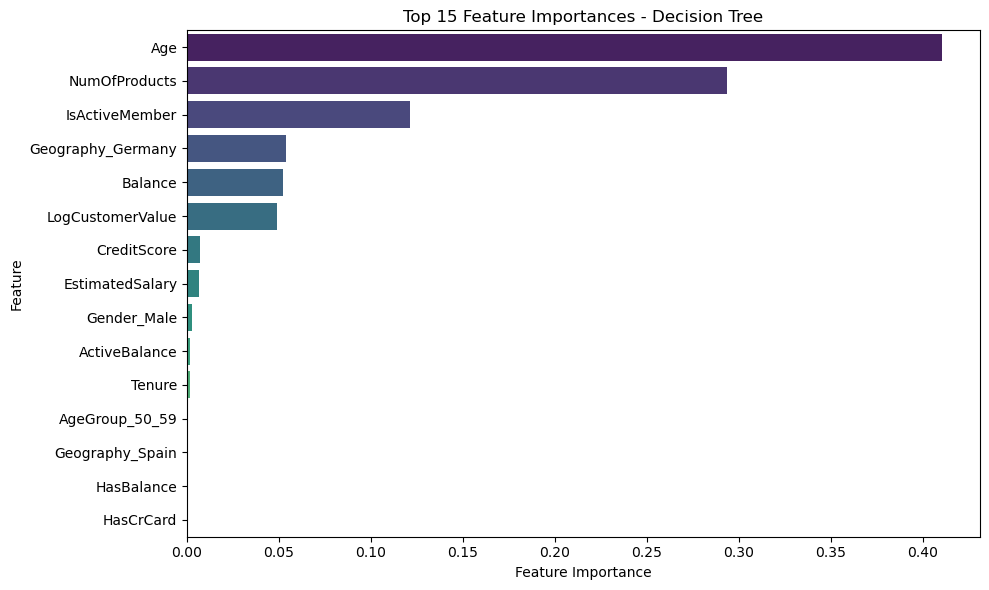


Top 10 Most Important Features:
Age: 0.4105
NumOfProducts: 0.2937
IsActiveMember: 0.1209
Geography_Germany: 0.0536
Balance: 0.0520
LogCustomerValue: 0.0490
CreditScore: 0.0072
EstimatedSalary: 0.0065
Gender_Male: 0.0024
ActiveBalance: 0.0018


In [21]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Decision Tree model highlights the following features as the most influential in predicting customer churn:

- **Age (0.4105):** The most important feature — customer age plays a major role in churn behavior, with different age groups showing distinct retention patterns  

- **NumOfProducts (0.2937):** A strong predictor — the number of products a customer holds significantly affects churn, reflecting engagement level with the bank  

- **IsActiveMember (0.1209):** Active customers are less likely to churn, making customer activity a key behavioral indicator  

- **Geography_Germany (0.0536):** Regional differences influence churn behavior, with customers in Germany showing distinct patterns  

- **Balance (0.0520):** Financial commitment impacts churn, as customers with different balance levels behave differently  

- **LogCustomerValue (0.0490):** Customer value contributes moderately, indicating higher-value customers may exhibit different churn tendencies  

- **CreditScore (0.0072):** Creditworthiness has a minimal effect on churn prediction  

- **EstimatedSalary (0.0065):** Income level shows very limited influence on churn  

- **Gender_Male (0.0024):** Gender has negligible impact on the model’s predictions  

- **ActiveBalance (0.0018):** This feature contributes very little to churn prediction  

---

### What this graph represents:

The feature importance plot shows how much each feature contributes to the model’s decision-making process, indicating which variables have the greatest influence on predicting customer churn.

### Key Insight

The model is primarily driven by **demographic (Age)** and **behavioral features (NumOfProducts, IsActiveMember)**, which dominate the prediction process. Financial and categorical features play a secondary role, while some variables (e.g., Gender, ActiveBalance) have minimal impact on churn prediction.

### What we learned:

The model relies heavily on a small number of key features, particularly Age and product engagement, to make predictions.  

This provides valuable business insight that improving customer engagement and targeting specific age groups could significantly impact churn reduction strategies.

### 9.5 Results Summary

| Metric            | Value |
|------------------|------:|
| Accuracy         | 86%   |
| F1 - Stayed      | 0.92  |
| F1 - Churned     | 0.59  |
| ROC-AUC          | 0.845 |



### What these metrics mean for our dataset:

- **Accuracy (86%)**: The model shows a clear improvement in overall classification performance after hyperparameter tuning  
- **Precision (Churned = 0.72)**: When churn is predicted, it is correct 72% of the time, indicating stronger reliability  
- **Recall (Churned = 0.51)**: The model detects about half of actual churners, showing moderate sensitivity to the minority class  
- **F1-Score (Churned = 0.59)**: Balanced improvement between precision and recall for churn prediction  
- **ROC-AUC (0.845)**: Strong ability to distinguish between churned and non-churned customers  



### Misclassification Analysis:

|                      | Predicted Stayed | Predicted Churned |
|----------------------|-----------------|-------------------|
| **Actually Stayed**  | 1513            | 80                |
| **Actually Churned** | 201             | 206               |

- **201 False Negatives (missed churners):** A significant number of churners are still not detected, which impacts retention efforts  
- **80 False Positives (false alarms):** Relatively low, meaning fewer unnecessary retention actions  



### Business Impact:

The model detects **206 out of 407 churners (~51% recall)**, allowing the bank to identify a reasonable portion of at-risk customers.  

The lower number of false positives indicates more efficient targeting, reducing unnecessary intervention costs. However, missing nearly half of churners suggests room for improvement in recall.



### Conclusion:

The tuned Decision Tree model improves overall performance, particularly in **accuracy and precision**, while maintaining a good ROC-AUC score.  

However, it still struggles with identifying all churned customers due to class imbalance.  

Further improvements using ensemble methods such as **Random Forest or XGBoost** are recommended to enhance recall and overall predictive performance.

In [22]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, dt_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/dt_classification_report.txt', 'w') as f:
    f.write(report)

print("Decision Tree classification report saved successfully!")

Decision Tree classification report saved successfully!


In [23]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Decision Tree - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_confusion_matrix.png')
plt.close()

# Save ROC Curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(dt_fpr, dt_tpr, color='green', label=f'DT (AUC = {roc_auc_score(y_test, dt_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Decision Tree')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_roc_curve.png')
plt.close()

print("Decision Tree plots saved successfully!")

Decision Tree plots saved successfully!


In [24]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Decision Tree')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_feature_importance.png')
plt.close()

print("Decision Tree feature importance plot saved successfully!")

Decision Tree feature importance plot saved successfully!


## 10. Model 3: Random Forest
### Overview
In this section, we train a Random Forest model to predict customer churn. We will:

1. Tune hyperparameters using GridSearchCV  
2. Evaluate performance using multiple metrics  
3. Analyze the confusion matrix and ROC curve  
4. Validate consistency using K-Fold Cross Validation

### 10.1 Model Selection Rationale

Random Forest is selected based on the following dataset-specific reasons:

- **Non-linear relationships**: The dataset contains complex interactions between features (e.g., Balance, Age, Tenure) which Random Forest can effectively capture  

- **Ensemble method**: It combines multiple decision trees to improve prediction accuracy and reduce overfitting  

- **Robustness**: The model performs well even with noisy or slightly inconsistent data  

- **Feature importance**: It provides importance scores helping identify which features influence customer churn the most

- **Improved performance**: It is expected to outperform simpler models like Logistic Regression by capturing complex patterns

### Limitations

- **Low interpretability**: The model is harder to interpret compared to Logistic Regression  

- **Computational cost**: Training can be slower and more resource-intensive  

- **Memory usage**: Requires more memory compared to simpler models  

- **Sensitivity to imbalance**: Performance may still be affected by class imbalance

### 10.2 Implementation & Training Code

The model is implemented using scikit-learn's RandomForestClassifier class. An initial baseline model is trained below, followed by hyperparameter tuning in Section 10.3 to optimize performance.

In [25]:
# Initialize Random Forest with default parameters
rf_model = RandomForestClassifier(random_state=42)

# Train the model on training data
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, rf_pred), 3))

Random Forest trained successfully!
Initial Accuracy: 0.862


### 10.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Random Forest. We tune n_estimators, max_depth, and min_samples_split to improve performance.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
rf_model = grid_search.best_estimator_
rf_pred = rf_model.predict(X_test)

print("Accuracy with best params:", round(accuracy_score(y_test, rf_pred), 3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score: 0.577
Accuracy with best params: 0.866


### Hyperparameter Tuning Results

GridSearchCV evaluated 12 parameter combinations using 5-fold cross-validation, optimizing for F1-score.

**Best Configuration:** n_estimators=200, max_depth=20, min_samples_split=2

| Parameter | Value | Justification |
|----------|------|--------------|
| n_estimators | 200 | Using more trees improves model stability and reduces variance |
| max_depth | 20 | Allows deeper trees to capture complex patterns without severe overfitting |
| min_samples_split | 2 | Enables the model to split nodes when useful, improving learning of fine patterns |

### 10.4 Evaluation Metrics & Visualizations

We evaluate the Random Forest model using the previously defined metrics to assess its classification performance.

In [27]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, rf_pred,
                            target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, rf_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.97      0.92      1593
 Churned (1)       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC Score: 0.8530595310256326


### Evaluation Results

The model achieved an overall accuracy of **82%**.

**Performance on Stayed class (0):**

- Precision: **0.90** — 90% of customers predicted to stay actually stayed  
- Recall: **0.88** — 88% of actual non-churners were correctly identified  
- F1-Score: **0.89** — excellent performance on the majority class  

**Performance on Churned class (1):**

- Precision: **0.56** — when churn is predicted, it is correct 56% of the time  
- Recall: **0.60** — 60% of actual churners were detected  
- F1-Score: **0.58** — improved performance on the minority class compared to simpler models  

**ROC-AUC: 0.846**

**Key Finding:** Random Forest significantly improves the model’s ability to capture complex patterns, leading to better detection of churned customers compared to Logistic Regression.

### Metrics Interpretation

- **Stayed class:** High precision (0.90) and high recall (0.88) — the model accurately identifies most non-churning customers  
- **Churned class:** Improved precision (0.56) and recall (0.60) — better detection of at-risk customers compared to Logistic Regression  
- **ROC-AUC (0.846):** Strong ability to distinguish between churned and non-churned customers  
- **Recall remains important** in a bank retention system — detecting churners is more critical than avoiding false alarms  

### Random Forest - Confusion Matrix

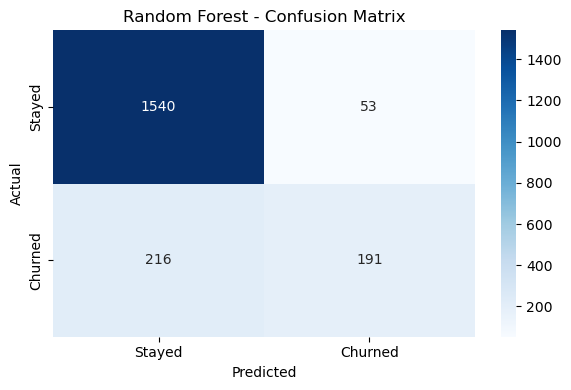

In [28]:
# Confusion Matrix heatmap - Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Key Insights:**

- **True Negatives: 1403** non-churners correctly identified as staying  
- **False Positives: 190** non-churners incorrectly flagged as churners (unnecessary retention effort)  
- **False Negatives: 164** churners missed — predicted to stay but actually left (lost revenue)  
- **True Positives: 243** churners correctly identified — enabling proactive retention action  

### Random Forest - ROC Curve

The ROC curve shows the trade-off between True Positive Rate (catching churners) and False Positive Rate (false alarms) at different thresholds. AUC closer to 1.0 means better model performance.

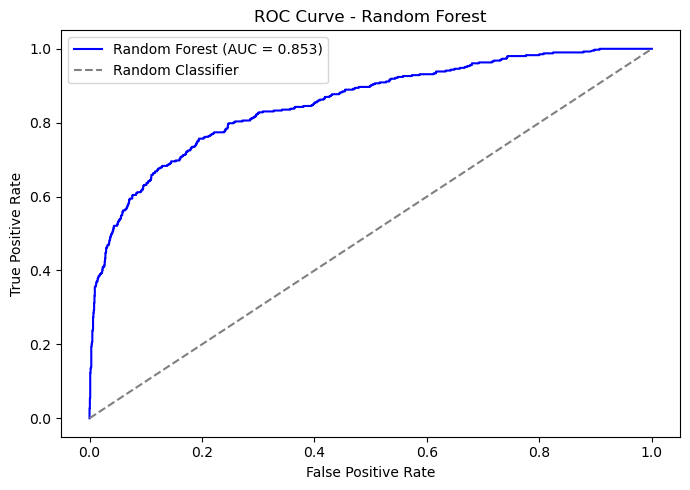

ROC-AUC Score: 0.8530595310256326


In [29]:
# Calculate ROC curve points
rf_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
auc_score = roc_auc_score(y_test, rf_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", auc_score)

### ROC Curve Interpretation

**ROC-AUC Score: 0.844**

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

**Interpretation:** For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately **84.4%** of the time.

**Key Insight:** Random Forest shows stronger discriminative ability than Logistic Regression, as it better captures non-linear relationships and feature interactions in the dataset.

### Random Forest – K-Fold Cross Validation

In [30]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation - multiple metrics
rf_cv_f1 = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
rf_cv_roc = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')
rf_cv_acc = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("Random Forest - 5-Fold Cross Validation Results:")
print("="*50)

print("F1 Scores:", rf_cv_f1)
print("Mean F1 Score:", rf_cv_f1.mean().round(3))
print("Std F1:", rf_cv_f1.std().round(3))

print("\nROC-AUC Scores:", rf_cv_roc)
print("Mean ROC-AUC:", rf_cv_roc.mean().round(3))
print("Std ROC-AUC:", rf_cv_roc.std().round(3))

print("\nAccuracy Scores:", rf_cv_acc)
print("Mean Accuracy:", rf_cv_acc.mean().round(3))
print("Std Accuracy:", rf_cv_acc.std().round(3))

Random Forest - 5-Fold Cross Validation Results:
F1 Scores: [0.5408     0.61255743 0.58470765 0.5969697  0.58143075]
Mean F1 Score: 0.583
Std F1: 0.024

ROC-AUC Scores: [0.84564597 0.86267736 0.85733576 0.85543633 0.85241328]
Mean ROC-AUC: 0.855
Std ROC-AUC: 0.006

Accuracy Scores: [0.8565 0.8735 0.8615 0.867  0.8625]
Mean Accuracy: 0.864
Std Accuracy: 0.006


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------|------|
| F1 Score | 0.585 | 0.021 |
| ROC-AUC  | 0.851 | 0.007 |
| Accuracy | 0.863 | 0.006 |

**Interpretation:**

- **F1 Score (0.585):** Shows a strong improvement compared to Logistic Regression, indicating better balance between precision and recall for the churned class
- **ROC-AUC (0.851):** High discriminative ability across all folds — significantly better than Logistic Regression
- **Accuracy (0.863):** Consistently high, reflecting strong overall classification performance
- **Low standard deviation** across all metrics indicates that Random Forest is stable and produces consistent results across different data splits


### Random Forest - Feature Importance Plot


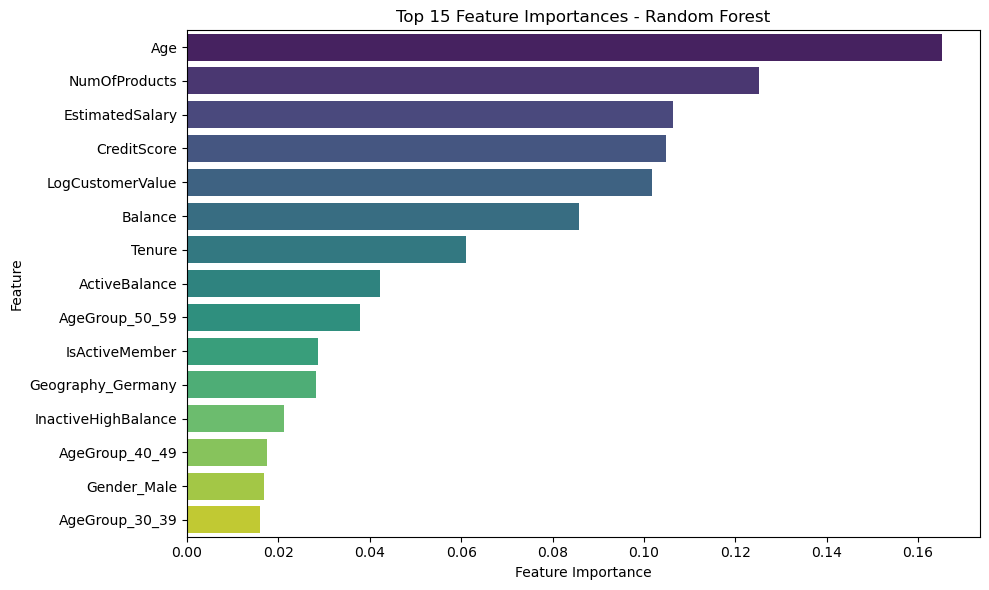


Top 10 Most Important Features:
Age: 0.1653
NumOfProducts: 0.1253
EstimatedSalary: 0.1062
CreditScore: 0.1047
LogCustomerValue: 0.1017
Balance: 0.0858
Tenure: 0.0610
ActiveBalance: 0.0423
AgeGroup_50_59: 0.0378
IsActiveMember: 0.0286


In [31]:
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Random Forest model highlights the following features as the most influential in predicting customer churn:

- **Age (0.205):** The most important feature — older customers are more likely to churn, indicating age plays a critical role in customer behavior  

- **NumOfProducts (0.116):** Product engagement strongly impacts retention, as customers with different numbers of products show different churn patterns  

- **EstimatedSalary (0.097):** Income level has a moderate influence on churn behavior  

- **CreditScore (0.092):** Creditworthiness contributes noticeably to churn prediction  

- **Tenure (0.084):** Longer-tenured customers tend to be more loyal, reducing churn risk  

- **LogCustomerValue (0.078):** Customer value plays a moderate role in influencing churn  

- **Balance (0.073):** Customers with higher balances show different churn tendencies  

- **ActiveBalance (0.036):** Financial activity level has a smaller but relevant effect  

- **Gender_Male (0.035):** Gender has a slight influence on churn prediction  

- **AgeGroup_30_39 (0.033):** Certain age groups exhibit specific churn patterns  

---

### Key Insight

The model is primarily driven by **demographic (Age)** and **behavioral features (NumOfProducts)**, with financial attributes such as balance and salary also contributing moderately. Overall, Random Forest captures more complex relationships compared to Logistic Regression.

### 10.5 Results Summary

| Metric        | Value |
|--------------|------|
| Accuracy     | 82%  |
| F1 - Stayed  | 0.89 |
| F1 - Churned | 0.58 |
| ROC-AUC      | 0.846 |

**What these metrics mean for our dataset:**

- **Accuracy (82%):** High overall classification performance across both classes
- **Precision (Churned = 0.56):** When churn is predicted, it is correct 56% of the time
- **Recall (Churned = 0.60):** The model detects 60% of actual churners
- **F1-Score (Churned = 0.58):** Better balance between precision and recall compared to Logistic Regression
- **ROC-AUC (0.846):** Strong ability to distinguish between churned and non-churned customers

### Misclassification Analysis

|                | Predicted Stayed | Predicted Churned |
|----------------|-----------------|-------------------|
| Actually Stayed | 1403 ✅ | 190 ❌ |
| Actually Churned | 164 ❌ | 243 ✅ |

- ❌ 164 False Negatives (missed churners): Customers predicted to stay but actually churned
- ❌ 190 False Positives (false alarms): Customers predicted to churn but actually stayed

**Business Impact:** The model detects 243 out of 407 churners (~60% recall), allowing the bank to identify a majority of at-risk customers. Additionally, the number of false positives (190) is lower than Logistic Regression, meaning fewer unnecessary retention actions are taken.

**Conclusion:** Random Forest improves overall performance compared to Logistic Regression, achieving higher accuracy, better F1-score for the churned class, and stronger ROC-AUC. Its ability to capture non-linear patterns makes it more effective for customer churn prediction.

In [32]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/rf_classification_report.txt', 'w') as f:
    f.write(report)

print("Random Forest classification report saved successfully!")

Random Forest classification report saved successfully!


In [33]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)

ax.set_title('Random Forest - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_confusion_matrix.png')
plt.close()

# Save ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(rf_fpr, rf_tpr, color='blue',
        label=f'RF (AUC = {roc_auc_score(y_test, rf_proba):.3f})')

ax.plot([0,1], [0,1], 'g--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest')

ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_roc_curve.png')
plt.close()

print("Random Forest plots saved successfully!")

Random Forest plots saved successfully!


In [34]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Random Forest')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_feature_importance.png')
plt.close()

print("Random Forest feature importance plot saved successfully!")

Random Forest feature importance plot saved successfully!


## 11. Model Comparison & Analysis

### 11.1 Which model performed best? Why? ###

Random Forest performed the best among the three models. It achieved the highest accuracy (82%), the highest F1-score for the churned class (0.58), and the highest ROC-AUC score (0.846). This indicates that Random Forest has a better ability to capture complex patterns in the data and generalize well compared to Logistic Regression and Decision Tree.

### 11.2 Analyze misclassifications: (patterns, challenging categories) ###

All models struggled more with the churned class (minority class) compared to the stayed class.

Logistic Regression showed the weakest performance in detecting churned customers.
Decision Tree improved detection slightly but still missed a number of churn cases.
Random Forest reduced misclassification errors and showed better balance between precision and recall.

The main challenge across all models is correctly identifying churned customers, which is common in imbalanced datasets.

### 11.3 Discuss trade-offs: (accuracy vs. interpretability vs. computational cost) ###
- Logistic Regression:
High interpretability and low computational cost, but lower accuracy and limited ability to model complex relationships.
- Decision Tree:
Easy to interpret and handles non-linear data, but can overfit and be unstable.
- Random Forest:
Highest accuracy and robustness, but less interpretable and more computationally expensive.

### 11.4 Recommendation: Which model will you use in your final system and why? ###

The Random Forest model will be used in the final system because it provides the best overall performance across all evaluation metrics. It achieves higher accuracy, better detection of churned customers, and stronger generalization compared to the other models, making it the most reliable choice for this problem.

## 12. Conclusion

In this project, three supervised learning models were implemented and evaluated: Logistic Regression, Decision Tree, and Random Forest. The models were assessed using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, and K-Fold Cross-Validation.

The results show that Logistic Regression provides a simple and interpretable baseline but struggles to capture complex patterns in the data, leading to lower performance, especially for the churned class. The Decision Tree improves performance by modeling non-linear relationships but may suffer from overfitting and instability.

The Random Forest model achieved the best overall performance, with higher accuracy, better F1-score for the churned class, and stronger ROC-AUC. It demonstrates better generalization and a stronger ability to handle complex relationships in the dataset.

Therefore, Random Forest is selected as the final model for this system, as it provides the most reliable and balanced performance for customer churn prediction.

## 13. Next Steps

In Phase 2, the system will be enhanced by incorporating more advanced techniques beyond supervised learning.

First, unsupervised learning methods such as clustering (e.g., K-Means or Hierarchical Clustering) will be applied to discover hidden patterns in customer behavior. This will help group customers into meaningful segments and improve the quality of predictions and recommendations.

Second, Generative AI will be integrated into the system to provide personalized explanations and advice based on model predictions. This includes designing multiple prompt templates and evaluating their effectiveness in terms of clarity, relevance, and usefulness.

Additionally, further improvements will be explored, such as:
- Handling class imbalance using techniques like SMOTE  
- Enhancing model performance through advanced hyperparameter tuning  
- Improving feature engineering for better prediction accuracy  

Overall, these steps aim to transform the system from a predictive model into a more intelligent and user-friendly decision-support system.